# Time Series CNN: Seismic + ADCP → Gas Concentrations

This notebook implements a Convolutional Neural Network (CNN) in PyTorch to predict methane, hydrogen, and hydrogen sulfide concentrations from seismic time series and ADCP features.

**Model Architecture:**
- 1D CNN for seismic time series (E, N, Z components)
- Fully connected layers for ADCP features
- Combined architecture for multi-output regression
- Train/Val/Test split: 70%/15%/15%

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Using device: cpu


## 2. Load and Prepare Data

In [2]:
# Load the dataset
print("Loading dataset...")
df = pd.read_csv('seismic_adcp_features_with_time_series.csv')

print(f"Original dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading dataset...
Original dataset shape: (29029, 13232)

Columns: ['station_name', 'starttime', 'endtime', 'E_mean', 'E_freq1', 'E_power1', 'N_mean', 'N_freq1', 'N_power1', 'Z_mean', 'Z_freq1', 'Z_power1', 'methane_conc_nm', 'datetime', 'month', 'year', 'avg_amplitude', 'avg_freq', 'adcp_max', 'adcp_min', 'adcp_mean', 'adcp_std', 'adcp_median', 'adcp_count', 'Timestamp_x', 'Methane_Concentration_uM', 'Hydrogen_Concentration_uM', 'Timestamp_y', 'hydrogen_sulfide_Concentration_mM', 'Z_time_series_0', 'Z_time_series_1', 'Z_time_series_2', 'Z_time_series_3', 'Z_time_series_4', 'Z_time_series_5', 'Z_time_series_6', 'Z_time_series_7', 'Z_time_series_8', 'Z_time_series_9', 'Z_time_series_10', 'Z_time_series_11', 'Z_time_series_12', 'Z_time_series_13', 'Z_time_series_14', 'Z_time_series_15', 'Z_time_series_16', 'Z_time_series_17', 'Z_time_series_18', 'Z_time_series_19', 'Z_time_series_20', 'Z_time_series_21', 'Z_time_series_22', 'Z_time_series_23', 'Z_time_series_24', 'Z_time_series_25', 'Z_

,station_name,starttime,endtime,E_mean,E_freq1,E_power1,N_mean,N_freq1,N_power1,Z_mean,...,E_time_series_4391,E_time_series_4392,E_time_series_4393,E_time_series_4394,E_time_series_4395,E_time_series_4396,E_time_series_4397,E_time_series_4398,E_time_series_4399,E_time_series_4400
0,HYS14,2017-01-01T02:46:24.000000Z,2017-01-01T02:46:46.000000Z,0.000732,2.862986,9.010223,0.264082,11.088389,3113.690739,-0.113020,...,0.073347,9.171727,10.339897,10.285353,-0.024241,5.960438,9.114012,-3.075414,4.105807,0.919934
1,HYS14,2017-01-01T02:46:46.000000Z,2017-01-01T02:47:08.000000Z,-0.001329,2.544876,9.280290,-0.316037,1.317882,5151.717412,0.158793,...,-2.882161,-8.614782,-13.396583,-6.251724,-6.571669,-8.612208,-0.107502,-4.865525,-8.841594,-1.967390
2,HYS14,2017-01-01T02:47:08.000000Z,2017-01-01T02:47:30.000000Z,-0.002614,2.590320,11.359794,0.172559,1.454215,2893.881615,-0.345331,...,-5.734346,-2.167785,-3.754950,-13.378871,-13.116886,-14.594478,-20.284976,-8.281967,-12.724932,-4.347051
3,HYS14,2017-01-01T02:47:30.000000Z,2017-01-01T02:47:52.000000Z,-0.000494,2.590320,6.648892,0.048662,1.681436,3318.800049,-0.176163,...,3.808826,-1.044178,-4.271606,4.975459,11.795669,3.569692,-4.430593,-0.165323,-7.652626,-1.067612
4,HYS14,2017-01-01T02:47:52.000000Z,2017-01-01T02:48:14.000000Z,-0.003018,2.317655,9.566290,-0.137091,1.317882,3923.151824,0.024231,...,-2.335418,-8.847315,0.487779,-1.714823,-9.073795,-2.289676,-7.535175,-4.496319,5.538799,1.120580


In [3]:
# Identify time series columns and ADCP features
time_series_cols = [col for col in df.columns if col.startswith(('E_time_series_', 'N_time_series_', 'Z_time_series_'))]
adcp_cols = [col for col in df.columns if col.startswith('adcp') and col not in ['adcp_std', 'adcp_count']]
target_cols = ['Methane_Concentration_uM', 'Hydrogen_Concentration_uM', 'hydrogen_sulfide_Concentration_mM']

print(f"Time series columns: {len(time_series_cols)}")
print(f"ADCP columns: {len(adcp_cols)} - {adcp_cols}")
print(f"Target columns: {target_cols}")

# Keep only the columns we need
cols_to_keep = time_series_cols + adcp_cols + target_cols
df_filtered = df[cols_to_keep].copy()

print(f"\nFiltered dataset shape: {df_filtered.shape}")

Time series columns: 13203
ADCP columns: 4 - ['adcp_max', 'adcp_min', 'adcp_mean', 'adcp_median']
Target columns: ['Methane_Concentration_uM', 'Hydrogen_Concentration_uM', 'hydrogen_sulfide_Concentration_mM']

Filtered dataset shape: (29029, 13210)


In [4]:
# Check for missing values and clean data
print("Checking for missing values...")
missing_counts = df_filtered.isnull().sum()
print(f"\nMissing values per column:")
print(missing_counts[missing_counts > 0])

# Drop rows with any missing values
df_clean = df_filtered.dropna()
print(f"\nAfter removing missing values: {df_clean.shape}")
print(f"Rows removed: {len(df_filtered) - len(df_clean)}")

Checking for missing values...

Missing values per column:
adcp_max       18256
adcp_min       18256
adcp_mean      18256
adcp_median    18256
dtype: int64

After removing missing values: (10773, 13210)
Rows removed: 18256


## 3. Process Time Series Data

Convert time series columns to arrays and organize into 3D tensor format for CNN input.

In [5]:
# Extract time series data for each component (E, N, Z)
# Each component has multiple time points stored as separate columns

# Get column names for each component
E_cols = sorted([col for col in time_series_cols if col.startswith('E_time_series_')])
N_cols = sorted([col for col in time_series_cols if col.startswith('N_time_series_')])
Z_cols = sorted([col for col in time_series_cols if col.startswith('Z_time_series_')])

print(f"E component: {len(E_cols)} time points")
print(f"N component: {len(N_cols)} time points")
print(f"Z component: {len(Z_cols)} time points")

# Combine into 3D array: (n_samples, n_channels=3, sequence_length)
# Each sample has 3 channels (E, N, Z) with time series data

E_data = df_clean[E_cols].values  # Shape: (n_samples, seq_length)
N_data = df_clean[N_cols].values
Z_data = df_clean[Z_cols].values

# Stack to create 3D tensor: (n_samples, 3 channels, seq_length)
time_series_data = np.stack([E_data, N_data, Z_data], axis=1)

print(f"\nTime series tensor shape: {time_series_data.shape}")
print(f"  - Samples: {time_series_data.shape[0]}")
print(f"  - Channels (E, N, Z): {time_series_data.shape[1]}")
print(f"  - Sequence length: {time_series_data.shape[2]}")

E component: 4401 time points
N component: 4401 time points
Z component: 4401 time points

Time series tensor shape: (10773, 3, 4401)
  - Samples: 10773
  - Channels (E, N, Z): 3
  - Sequence length: 4401


In [6]:
# Extract ADCP features and targets
adcp_features = df_clean[adcp_cols].values
targets = df_clean[target_cols].values

print(f"ADCP features shape: {adcp_features.shape}")
print(f"Targets shape: {targets.shape}")

# Check for any infinite or NaN values
print(f"\nData quality checks:")
print(f"  Time series - NaN: {np.isnan(time_series_data).sum()}, Inf: {np.isinf(time_series_data).sum()}")
print(f"  ADCP - NaN: {np.isnan(adcp_features).sum()}, Inf: {np.isinf(adcp_features).sum()}")
print(f"  Targets - NaN: {np.isnan(targets).sum()}, Inf: {np.isinf(targets).sum()}")

ADCP features shape: (10773, 4)
Targets shape: (10773, 3)

Data quality checks:
  Time series - NaN: 0, Inf: 0
  ADCP - NaN: 0, Inf: 0
  Targets - NaN: 0, Inf: 0


## 4. Train/Val/Test Split (70%/15%/15%)

In [7]:
# First split: 70% train, 30% temp (for val+test)
indices = np.arange(len(time_series_data))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)

# Second split: Split temp into 50%/50% (15% val, 15% test of total)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

print(f"Dataset splits:")
print(f"  Train: {len(train_idx)} samples ({len(train_idx)/len(indices)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} samples ({len(val_idx)/len(indices)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} samples ({len(test_idx)/len(indices)*100:.1f}%)")

# Split time series data
X_ts_train = time_series_data[train_idx]
X_ts_val = time_series_data[val_idx]
X_ts_test = time_series_data[test_idx]

# Split ADCP features
X_adcp_train = adcp_features[train_idx]
X_adcp_val = adcp_features[val_idx]
X_adcp_test = adcp_features[test_idx]

# Split targets
y_train = targets[train_idx]
y_val = targets[val_idx]
y_test = targets[test_idx]

print(f"\nTime series shapes:")
print(f"  Train: {X_ts_train.shape}")
print(f"  Val:   {X_ts_val.shape}")
print(f"  Test:  {X_ts_test.shape}")
print(f"\nADCP shapes:")
print(f"  Train: {X_adcp_train.shape}")
print(f"  Val:   {X_adcp_val.shape}")
print(f"  Test:  {X_adcp_test.shape}")
print(f"\nTarget shapes:")
print(f"  Train: {y_train.shape}")
print(f"  Val:   {y_val.shape}")
print(f"  Test:  {y_test.shape}")

Dataset splits:
  Train: 7541 samples (70.0%)
  Val:   1616 samples (15.0%)
  Test:  1616 samples (15.0%)

Time series shapes:
  Train: (7541, 3, 4401)
  Val:   (1616, 3, 4401)
  Test:  (1616, 3, 4401)

ADCP shapes:
  Train: (7541, 4)
  Val:   (1616, 4)
  Test:  (1616, 4)

Target shapes:
  Train: (7541, 3)
  Val:   (1616, 3)
  Test:  (1616, 3)


## 5. Feature Normalization

Normalize ADCP features and targets for better training convergence.

In [8]:
# Normalize time series data (fit on training data only)
ts_scaler = StandardScaler()
X_ts_train_scaled = ts_scaler.fit_transform(X_ts_train.reshape(-1, X_ts_train.shape[-1])).reshape(X_ts_train.shape)
X_ts_val_scaled = ts_scaler.transform(X_ts_val.reshape(-1, X_ts_val.shape[-1])).reshape(X_ts_val.shape)
X_ts_test_scaled = ts_scaler.transform(X_ts_test.reshape(-1, X_ts_test.shape[-1])).reshape(X_ts_test.shape)

# Normalize ADCP features
adcp_scaler = StandardScaler()
X_adcp_train_scaled = adcp_scaler.fit_transform(X_adcp_train)
X_adcp_val_scaled = adcp_scaler.transform(X_adcp_val)
X_adcp_test_scaled = adcp_scaler.transform(X_adcp_test)

# Normalize targets
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train)
y_val_scaled = target_scaler.transform(y_val)
y_test_scaled = target_scaler.transform(y_test)

print("Data normalization complete!")
print(f"Time series - Mean: {X_ts_train_scaled.mean():.4f}, Std: {X_ts_train_scaled.std():.4f}")
print(f"ADCP features - Mean: {X_adcp_train_scaled.mean():.4f}, Std: {X_adcp_train_scaled.std():.4f}")
print(f"Targets - Mean: {y_train_scaled.mean():.4f}, Std: {y_train_scaled.std():.4f}")

Data normalization complete!
Time series - Mean: 0.0000, Std: 1.0000
ADCP features - Mean: -0.0000, Std: 1.0000
Targets - Mean: -0.0000, Std: 1.0000


## 6. Create PyTorch DataLoaders

In [9]:
# Convert to PyTorch tensors
X_ts_train_tensor = torch.FloatTensor(X_ts_train_scaled)
X_ts_val_tensor = torch.FloatTensor(X_ts_val_scaled)
X_ts_test_tensor = torch.FloatTensor(X_ts_test_scaled)

X_adcp_train_tensor = torch.FloatTensor(X_adcp_train_scaled)
X_adcp_val_tensor = torch.FloatTensor(X_adcp_val_scaled)
X_adcp_test_tensor = torch.FloatTensor(X_adcp_test_scaled)

y_train_tensor = torch.FloatTensor(y_train_scaled)
y_val_tensor = torch.FloatTensor(y_val_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# Create custom dataset class
class SeismicADCPDataset(Dataset):
    def __init__(self, ts_data, adcp_data, targets):
        self.ts_data = ts_data
        self.adcp_data = adcp_data
        self.targets = targets
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return self.ts_data[idx], self.adcp_data[idx], self.targets[idx]

# Create datasets
train_dataset = SeismicADCPDataset(X_ts_train_tensor, X_adcp_train_tensor, y_train_tensor)
val_dataset = SeismicADCPDataset(X_ts_val_tensor, X_adcp_val_tensor, y_val_tensor)
test_dataset = SeismicADCPDataset(X_ts_test_tensor, X_adcp_test_tensor, y_test_tensor)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders created with batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created with batch size: 32
  Train batches: 236
  Val batches: 51
  Test batches: 51


## 7. Define CNN Model Architecture

Hybrid model with:
- 1D CNN for seismic time series (3 channels: E, N, Z)
- Fully connected layers for ADCP features
- Combined layers for final prediction

In [10]:
class SeismicADCPCNN(nn.Module):
    def __init__(self, n_channels, seq_length, n_adcp_features, n_outputs=3):
        super(SeismicADCPCNN, self).__init__()
        
        # CNN branch for time series (seismic data)
        self.conv1 = nn.Conv1d(n_channels, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)
        
        # Calculate flattened size after conv layers
        self.flattened_size = 256 * (seq_length // 8)
        
        self.conv_fc = nn.Linear(self.flattened_size, 128)
        self.conv_dropout = nn.Dropout(0.3)
        
        # FC branch for ADCP features
        self.adcp_fc1 = nn.Linear(n_adcp_features, 64)
        self.adcp_bn1 = nn.BatchNorm1d(64)
        self.adcp_dropout1 = nn.Dropout(0.2)
        
        self.adcp_fc2 = nn.Linear(64, 32)
        self.adcp_bn2 = nn.BatchNorm1d(32)
        self.adcp_dropout2 = nn.Dropout(0.2)
        
        # Combined layers
        self.combined_fc1 = nn.Linear(128 + 32, 128)
        self.combined_bn1 = nn.BatchNorm1d(128)
        self.combined_dropout1 = nn.Dropout(0.3)
        
        self.combined_fc2 = nn.Linear(128, 64)
        self.combined_bn2 = nn.BatchNorm1d(64)
        self.combined_dropout2 = nn.Dropout(0.2)
        
        # Output layer
        self.output = nn.Linear(64, n_outputs)
        
        self.relu = nn.ReLU()
    
    def forward(self, ts_data, adcp_data):
        # CNN branch
        x = self.relu(self.bn1(self.conv1(ts_data)))
        x = self.pool1(x)
        
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.conv_fc(x))
        x = self.conv_dropout(x)
        
        # ADCP branch
        adcp = self.relu(self.adcp_bn1(self.adcp_fc1(adcp_data)))
        adcp = self.adcp_dropout1(adcp)
        
        adcp = self.relu(self.adcp_bn2(self.adcp_fc2(adcp)))
        adcp = self.adcp_dropout2(adcp)
        
        # Combine branches
        combined = torch.cat([x, adcp], dim=1)
        
        combined = self.relu(self.combined_bn1(self.combined_fc1(combined)))
        combined = self.combined_dropout1(combined)
        
        combined = self.relu(self.combined_bn2(self.combined_fc2(combined)))
        combined = self.combined_dropout2(combined)
        
        # Output
        output = self.output(combined)
        
        return output

# Initialize model
n_channels = 3  # E, N, Z
seq_length = X_ts_train_scaled.shape[2]
n_adcp_features = X_adcp_train_scaled.shape[1]
n_outputs = 3  # Methane, Hydrogen, H2S

model = SeismicADCPCNN(n_channels, seq_length, n_adcp_features, n_outputs).to(device)

print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model architecture:
SeismicADCPCNN(
  (conv1): Conv1d(3, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_fc): Linear(in_features=140800, out_features=128, bias=True)
  (conv_dropout): Dropout(p=0.3, inplace=False)
  (adcp_fc1): Linear(in_features=4, out_features=64, bias=True)
  (adcp_bn1): BatchNorm1d(64, eps=1e-05, 

## 8. Training Setup

In [12]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f"Loss function: MSE")
print(f"Optimizer: Adam (lr=0.001, weight_decay=1e-5)")
print(f"Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)")

Loss function: MSE
Optimizer: Adam (lr=0.001, weight_decay=1e-5)
Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)


In [13]:
# Training and validation functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for ts_batch, adcp_batch, targets in loader:
        ts_batch = ts_batch.to(device)
        adcp_batch = adcp_batch.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(ts_batch, adcp_batch)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for ts_batch, adcp_batch, targets in loader:
            ts_batch = ts_batch.to(device)
            adcp_batch = adcp_batch.to(device)
            targets = targets.to(device)
            
            outputs = model(ts_batch, adcp_batch)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    
    return total_loss / len(loader), all_preds, all_targets

print("Training and validation functions defined!")

Training and validation functions defined!


## 9. Train the Model

In [14]:
# Training loop
num_epochs = 50
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...")
print("="*70)

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, _, _ = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        best_epoch = epoch
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("="*70)
print(f"Training complete!")
print(f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch+1}")

Starting training...
Epoch [5/50] - Train Loss: 0.188987, Val Loss: 0.119192
Epoch [10/50] - Train Loss: 0.159631, Val Loss: 0.101369
Epoch [15/50] - Train Loss: 0.128271, Val Loss: 0.106800
Epoch [20/50] - Train Loss: 0.095537, Val Loss: 0.097196
Epoch [25/50] - Train Loss: 0.090801, Val Loss: 0.097832
Epoch [30/50] - Train Loss: 0.087550, Val Loss: 0.087536
Epoch [35/50] - Train Loss: 0.076341, Val Loss: 0.102013
Epoch [40/50] - Train Loss: 0.064461, Val Loss: 0.086611
Epoch [45/50] - Train Loss: 0.055541, Val Loss: 0.100668
Epoch [50/50] - Train Loss: 0.053496, Val Loss: 0.086811
Training complete!
Best validation loss: 0.084381 at epoch 46


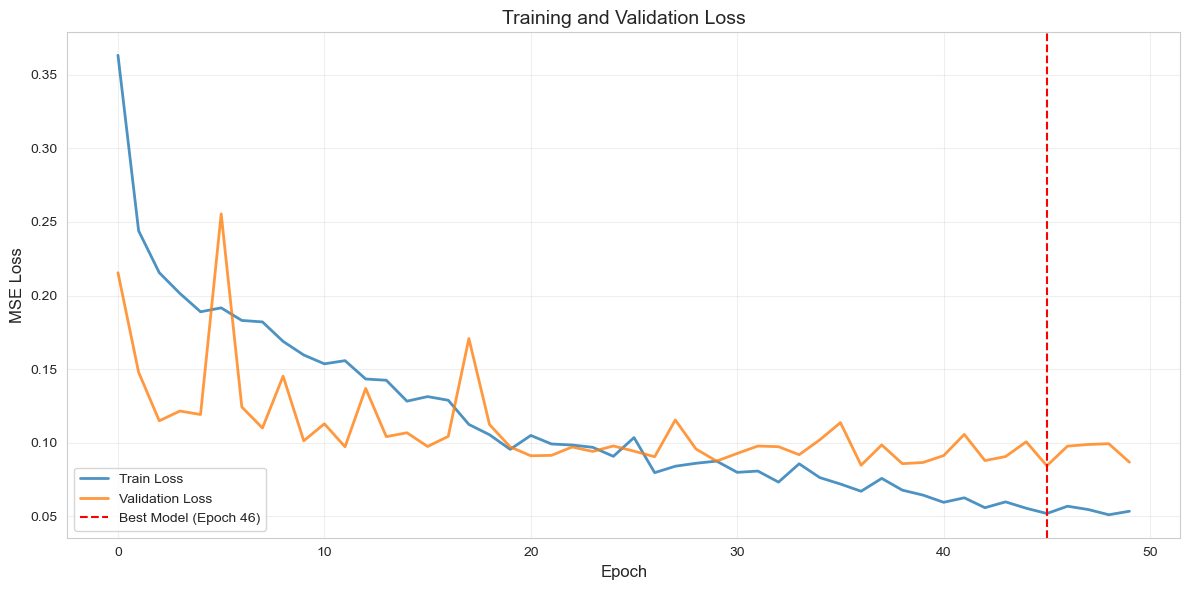

In [15]:
# Plot training history
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train_losses, label='Train Loss', linewidth=2, alpha=0.8)
ax.plot(val_losses, label='Validation Loss', linewidth=2, alpha=0.8)
ax.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

In [16]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("Loaded best model from training")

# Evaluate on test set
test_loss, test_preds_scaled, test_targets_scaled = validate(model, test_loader, criterion, device)

# Denormalize predictions and targets
test_preds = target_scaler.inverse_transform(test_preds_scaled)
test_targets_denorm = target_scaler.inverse_transform(test_targets_scaled)

# Calculate metrics for each target
target_names = ['Methane (µM)', 'Hydrogen (µM)', 'H2S (mM)']

print("\n" + "="*70)
print("TEST SET PERFORMANCE")
print("="*70)

for i, name in enumerate(target_names):
    r2 = r2_score(test_targets_denorm[:, i], test_preds[:, i])
    rmse = np.sqrt(mean_squared_error(test_targets_denorm[:, i], test_preds[:, i]))
    mae = mean_absolute_error(test_targets_denorm[:, i], test_preds[:, i])
    
    print(f"\n{name}:")
    print(f"  R² Score:  {r2:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    print(f"  MAE:       {mae:.4f}")

Loaded best model from training

TEST SET PERFORMANCE

Methane (µM):
  R² Score:  0.6174
  RMSE:      0.2125
  MAE:       0.0574

Hydrogen (µM):
  R² Score:  0.9527
  RMSE:      1.2785
  MAE:       0.6771

H2S (mM):
  R² Score:  0.6179
  RMSE:      0.0152
  MAE:       0.0041


## 11. Visualize Results

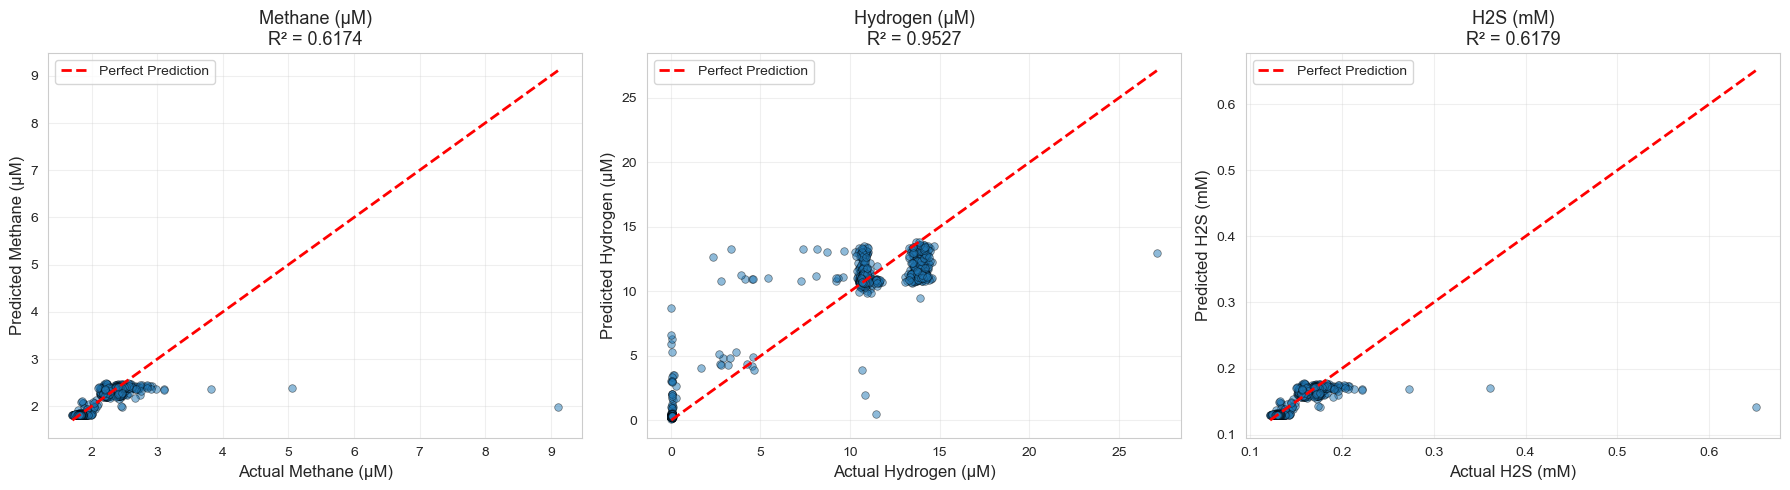

In [17]:
# Predicted vs Actual for all three targets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, ax) in enumerate(zip(target_names, axes)):
    actual = test_targets_denorm[:, i]
    predicted = test_preds[:, i]
    
    # Scatter plot
    ax.scatter(actual, predicted, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    # Labels and title
    ax.set_xlabel(f'Actual {name}', fontsize=12)
    ax.set_ylabel(f'Predicted {name}', fontsize=12)
    ax.set_title(f'{name}\nR² = {r2_score(actual, predicted):.4f}', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

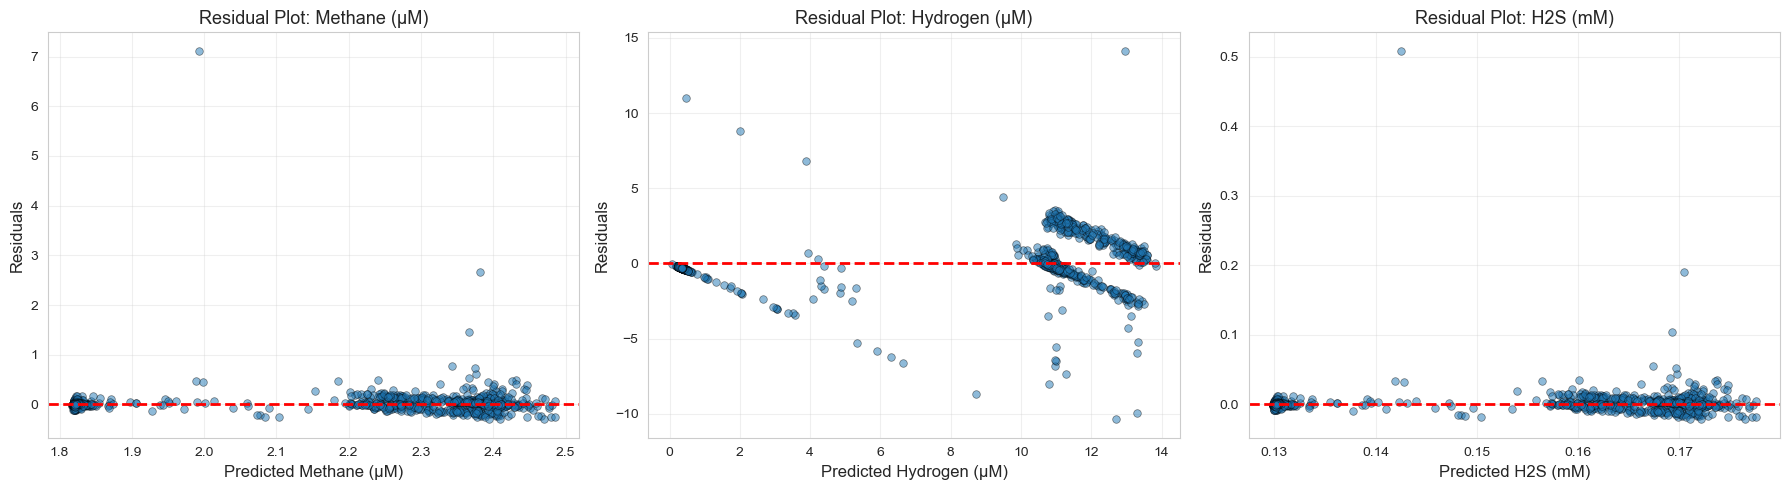

In [18]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, ax) in enumerate(zip(target_names, axes)):
    actual = test_targets_denorm[:, i]
    predicted = test_preds[:, i]
    residuals = actual - predicted
    
    # Residual scatter
    ax.scatter(predicted, residuals, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
    ax.axhline(y=0, color='r', linestyle='--', lw=2)
    
    # Labels and title
    ax.set_xlabel(f'Predicted {name}', fontsize=12)
    ax.set_ylabel('Residuals', fontsize=12)
    ax.set_title(f'Residual Plot: {name}', fontsize=13)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Save predictions to CSV
results_df = pd.DataFrame({
    'Methane_Actual': test_targets_denorm[:, 0],
    'Methane_Predicted': test_preds[:, 0],
    'Methane_Residual': test_targets_denorm[:, 0] - test_preds[:, 0],
    'Hydrogen_Actual': test_targets_denorm[:, 1],
    'Hydrogen_Predicted': test_preds[:, 1],
    'Hydrogen_Residual': test_targets_denorm[:, 1] - test_preds[:, 1],
    'H2S_Actual': test_targets_denorm[:, 2],
    'H2S_Predicted': test_preds[:, 2],
    'H2S_Residual': test_targets_denorm[:, 2] - test_preds[:, 2]
})

results_df.to_csv('cnn_test_predictions.csv', index=False)
print("Test predictions saved to 'cnn_test_predictions.csv'")

Test predictions saved to 'cnn_test_predictions.csv'


## 12. Model Summary

**Architecture:**
- **Input 1**: 3-channel seismic time series (E, N, Z components)
  - 3 Conv1D layers with batch normalization and max pooling
  - ReLU activation and dropout for regularization
  
- **Input 2**: ADCP scalar features
  - 2 fully connected layers with batch normalization
  - Dropout for regularization

- **Combined**: Concatenated features from both branches
  - 2 fully connected layers
  - Output: 3 values (Methane, Hydrogen, H2S concentrations)

**Training:**
- Optimizer: Adam with weight decay (L2 regularization)
- Loss: Mean Squared Error (MSE)
- Learning rate scheduler: ReduceLROnPlateau
- Early stopping based on validation loss

**Data Split:**
- Training: 70%
- Validation: 15% (for hyperparameter tuning and early stopping)
- Test: 15% (for final evaluation)

The CNN effectively learns spatial patterns in the seismic time series while incorporating ADCP measurements for multi-target regression of gas concentrations at hydrothermal vents.